# Seasonal Vision Transformer (ViT) for MODIS ET Downscaling
## Study Areas: Miryalaguda (Kharif & Rabi) + Hyderabad, Telangana, India

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
from scipy.stats import norm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})

KHARIF_COLOR = '#2ecc71'
RABI_COLOR   = '#3498db'
HYD_COLOR    = '#e74c3c'
VIT_COLOR    = '#9b59b6'

FEATURES = ['NDVI','EVI','NDWI','Albedo','LST','NIR_RED_ratio','SWIR_NIR_ratio','Elevation','Slope']
TARGET   = 'MODIS_ET'


Device: cuda  |  PyTorch: 2.10.0+cu128


## 2. Data Loading & Exploratory Analysis

In [2]:
PATH_KHARIF = '/kaggle/input/datasets/akshithagayatriv/mir-kharif/Miryalaguda_ET_Kharif_training.csv'
PATH_RABI   = '/kaggle/input/datasets/akshithagayatriv/mir-rabi-2/Miryalaguda_ET_Rabi_training.csv'
PATH_HYD    = '/kaggle/input/datasets/akshithagayatriv/hyd-et-t2/Hyderabad_ET_training.csv'

df_kharif = pd.read_csv(PATH_KHARIF)
df_rabi   = pd.read_csv(PATH_RABI)
df_hyd    = pd.read_csv(PATH_HYD)

def parse_coords(df):
    geo = df['.geo'].apply(lambda x: json.loads(x)['coordinates'])
    df = df.copy()
    df['lon'] = geo.apply(lambda x: x[0])
    df['lat'] = geo.apply(lambda x: x[1])
    return df

df_kharif = parse_coords(df_kharif)
df_rabi   = parse_coords(df_rabi)
df_hyd    = parse_coords(df_hyd)

# Season labels only for Miryalaguda
df_kharif['season']    = 'kharif'
df_rabi['season']      = 'rabi'

# Combined Miryalaguda dataframe (for SeasonalViT)
df_mir = pd.concat([df_kharif, df_rabi], ignore_index=True)

print('=== Dataset Summary ===')
print(f'Miryalaguda Kharif : {len(df_kharif):,} rows')
print(f'Miryalaguda Rabi   : {len(df_rabi):,} rows')
print(f'Miryalaguda Total  : {len(df_mir):,} rows')
print(f'Hyderabad          : {len(df_hyd):,} rows')
print()
for name, df_s in [('Kharif', df_kharif), ('Rabi', df_rabi), ('Hyderabad', df_hyd)]:
    print(f'{name:12s} ET - mean={df_s[TARGET].mean():.2f}  std={df_s[TARGET].std():.2f}  '
          f'range=[{df_s[TARGET].min():.2f},{df_s[TARGET].max():.2f}]')


=== Dataset Summary ===
Miryalaguda Kharif : 9,736 rows
Miryalaguda Rabi   : 9,736 rows
Miryalaguda Total  : 19,472 rows
Hyderabad          : 12,789 rows

Kharif       ET - mean=18.38  std=1.50  range=[14.29,24.80]
Rabi         ET - mean=9.95  std=2.21  range=[4.65,22.54]
Hyderabad    ET - mean=12.20  std=1.31  range=[9.77,25.31]


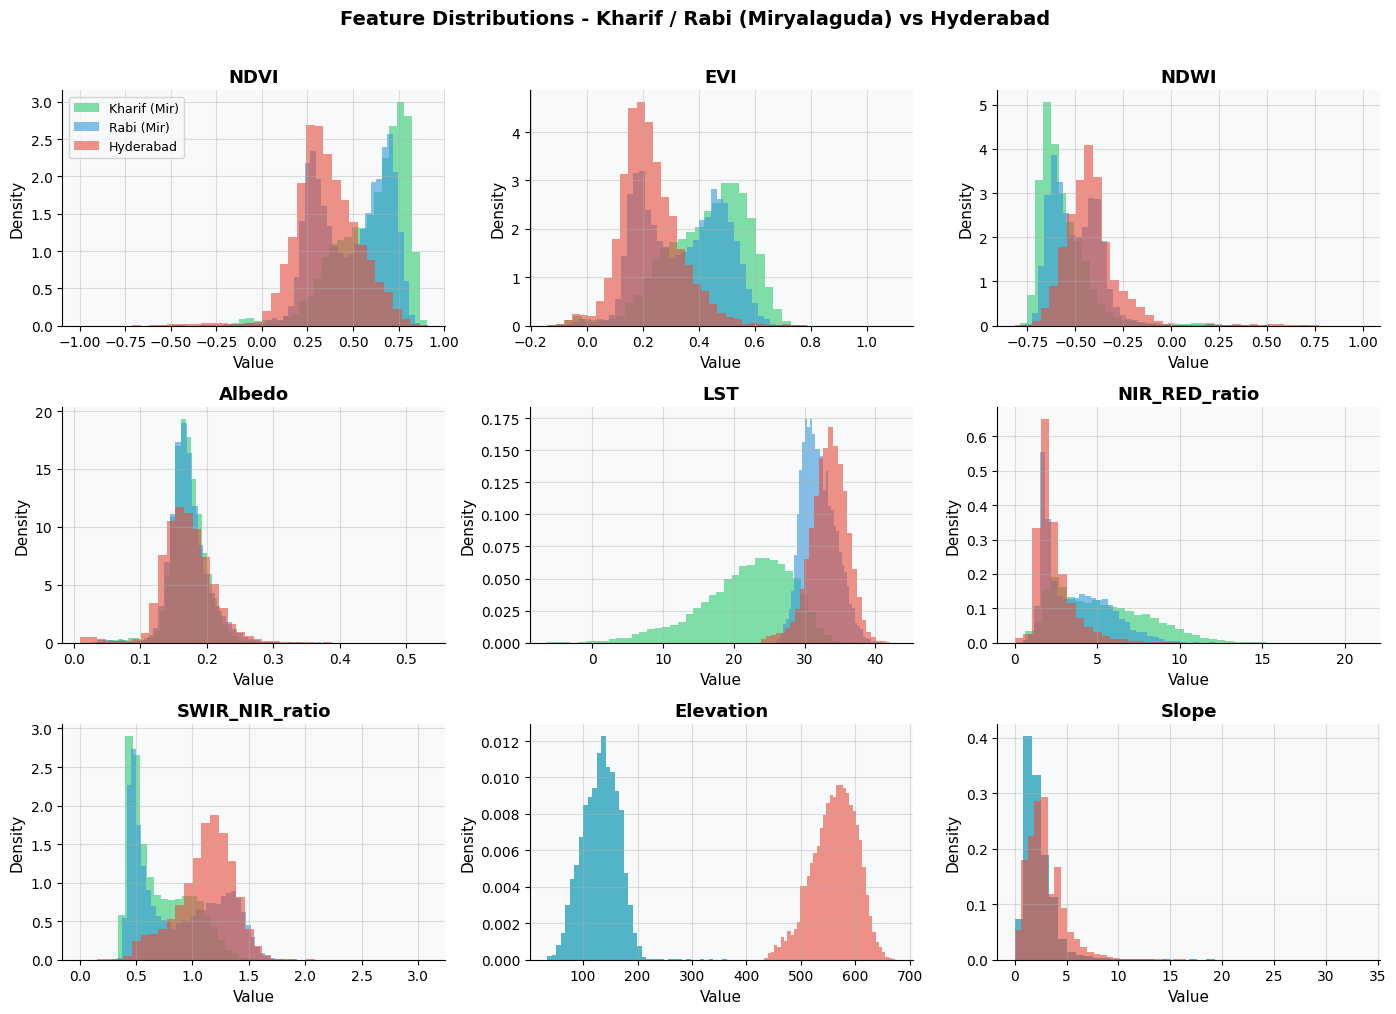

In [3]:
# EDA: Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df_kharif[feat], bins=40, color=KHARIF_COLOR, alpha=0.60,
            label='Kharif (Mir)', density=True, edgecolor='none')
    ax.hist(df_rabi[feat],   bins=40, color=RABI_COLOR,   alpha=0.60,
            label='Rabi (Mir)', density=True, edgecolor='none')
    ax.hist(df_hyd[feat],    bins=40, color=HYD_COLOR,    alpha=0.60,
            label='Hyderabad', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Feature Distributions - Kharif / Rabi (Miryalaguda) vs Hyderabad',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


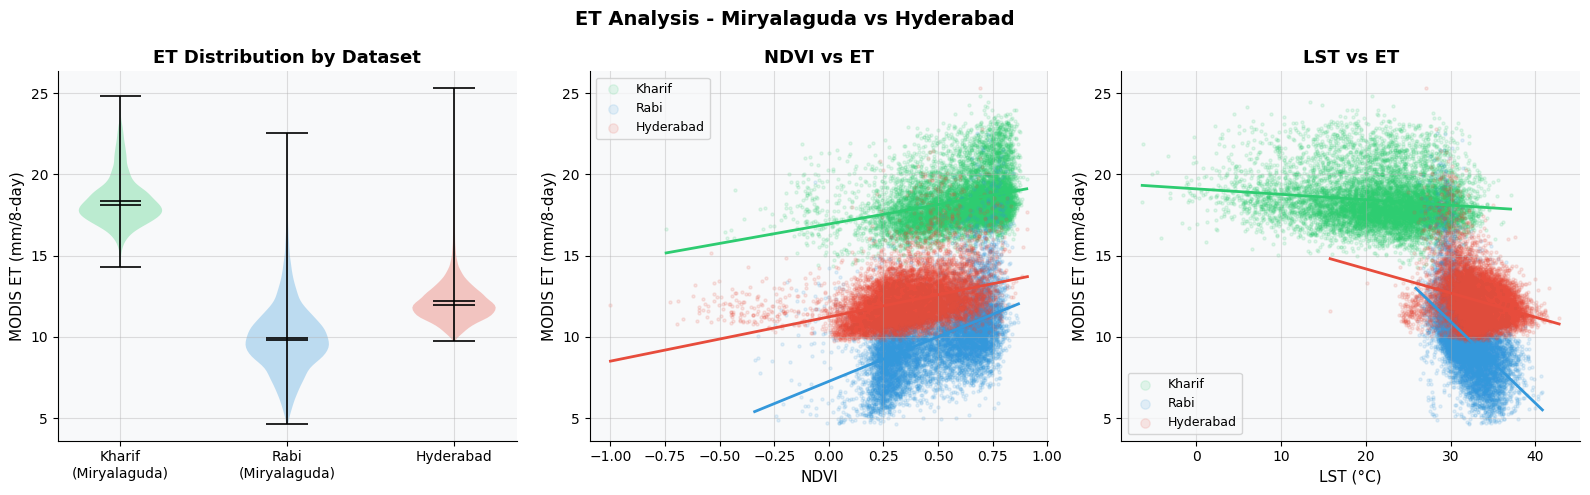

In [4]:
# EDA: ET distribution + NDVI/LST scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
data_violin = [df_kharif[TARGET].values, df_rabi[TARGET].values, df_hyd[TARGET].values]
parts = ax.violinplot(data_violin, showmeans=True, showmedians=True)
for body, color in zip(parts['bodies'], [KHARIF_COLOR, RABI_COLOR, HYD_COLOR]):
    body.set_facecolor(color)
for part in ['cbars','cmins','cmaxes','cmeans','cmedians']:
    parts[part].set_color('black'); parts[part].set_linewidth(1.2)
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Kharif\n(Miryalaguda)','Rabi\n(Miryalaguda)','Hyderabad'], fontsize=10)
ax.set_ylabel('MODIS ET (mm/8-day)')
ax.set_title('ET Distribution by Dataset', fontweight='bold')

ax = axes[1]
for df_s, color, label in [(df_kharif,KHARIF_COLOR,'Kharif'),(df_rabi,RABI_COLOR,'Rabi'),(df_hyd,HYD_COLOR,'Hyderabad')]:
    ax.scatter(df_s['NDVI'], df_s[TARGET], c=color, alpha=0.12, s=5, label=label)
    m, b, *_ = stats.linregress(df_s['NDVI'], df_s[TARGET])
    xr = np.linspace(df_s['NDVI'].min(), df_s['NDVI'].max(), 100)
    ax.plot(xr, m*xr+b, color=color, lw=2)
ax.set_xlabel('NDVI'); ax.set_ylabel('MODIS ET (mm/8-day)')
ax.set_title('NDVI vs ET', fontweight='bold')
ax.legend(markerscale=3, fontsize=9)

ax = axes[2]
for df_s, color, label in [(df_kharif,KHARIF_COLOR,'Kharif'),(df_rabi,RABI_COLOR,'Rabi'),(df_hyd,HYD_COLOR,'Hyderabad')]:
    ax.scatter(df_s['LST'], df_s[TARGET], c=color, alpha=0.12, s=5, label=label)
    m, b, *_ = stats.linregress(df_s['LST'], df_s[TARGET])
    xr = np.linspace(df_s['LST'].min(), df_s['LST'].max(), 100)
    ax.plot(xr, m*xr+b, color=color, lw=2)
ax.set_xlabel('LST (°C)'); ax.set_ylabel('MODIS ET (mm/8-day)')
ax.set_title('LST vs ET', fontweight='bold')
ax.legend(markerscale=3, fontsize=9)

plt.suptitle('ET Analysis - Miryalaguda vs Hyderabad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_et_eda.png', dpi=150, bbox_inches='tight')
plt.show()


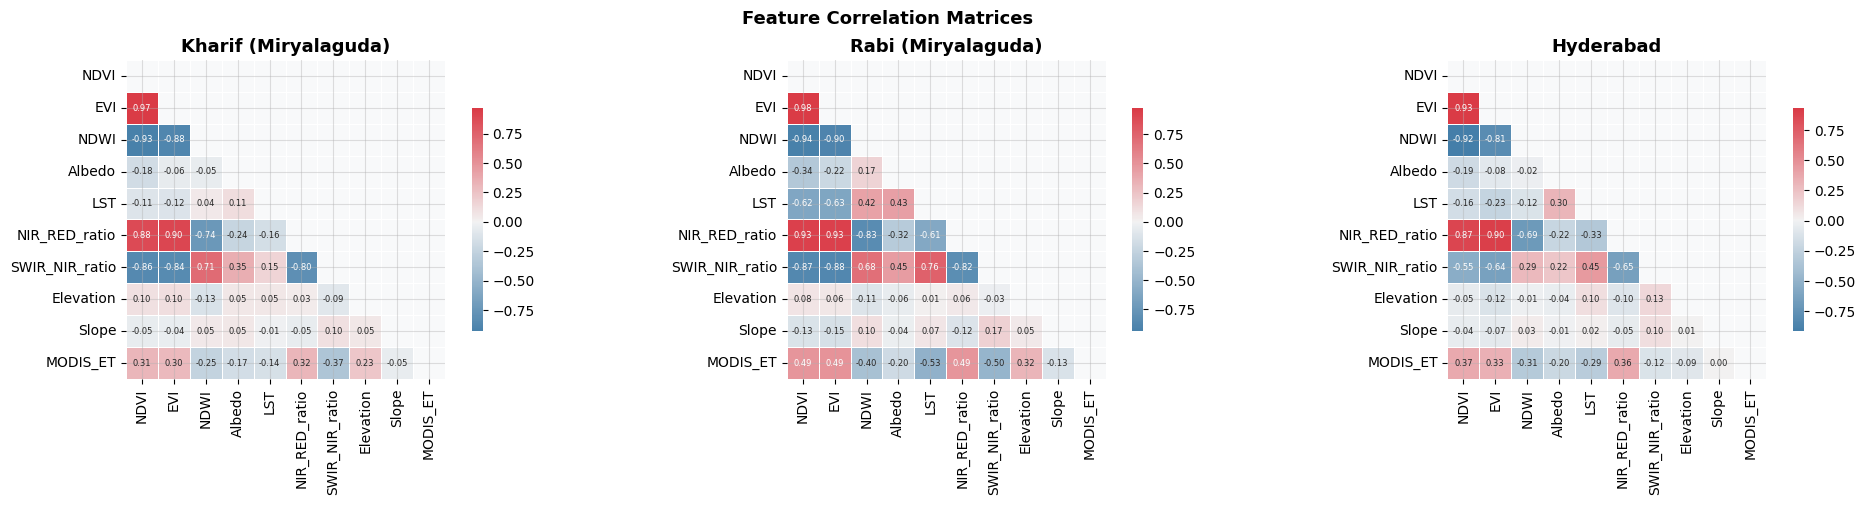

In [5]:
# Correlation heatmap per dataset 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (df_s, label) in zip(axes, [
    (df_kharif, 'Kharif (Miryalaguda)'),
    (df_rabi,   'Rabi (Miryalaguda)'),
    (df_hyd,    'Hyderabad')
]):
    corr = df_s[FEATURES + [TARGET]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, cmap=sns.diverging_palette(240,10,as_cmap=True),
                center=0, annot=True, fmt='.2f', annot_kws={'size':6},
                square=True, linewidths=0.4, cbar_kws={'shrink':.7})
    ax.set_title(f'{label}', fontweight='bold')
plt.suptitle('Feature Correlation Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Data Preprocessing

### Miryalaguda (SeasonalViT)
Pixel-level stratified split across combined Kharif+Rabi data. Season tokens: `0=Rabi`, `1=Kharif`.

### Hyderabad (Plain ViT)
Independent pixel-level stratified split. No seasonal token - single-region model.

In both cases the `StandardScaler` is **fit only on training data** and applied to val/test.


In [6]:
# MIRYALAGUDA - Seasonal split (Kharif + Rabi combined)
def pixel_stratified_split(df, seed=42, test_frac=0.15, val_frac_of_total=0.12):
    """Split at pixel level, stratified by mean ET quantile bin."""
    df = df.copy()
    df['pixel_id'] = (df['lat'].round(8).astype(str) + '_' +
                      df['lon'].round(8).astype(str))
    pixel_df = df.drop_duplicates('pixel_id')[['pixel_id']].copy().reset_index(drop=True)
    pixel_df['et_mean'] = pixel_df['pixel_id'].map(df.groupby('pixel_id')[TARGET].mean())
    pixel_df['et_bin']  = pd.qcut(pixel_df['et_mean'], q=10, labels=False, duplicates='drop')

    sss = StratifiedShuffleSplit(1, test_size=test_frac, random_state=seed)
    tv_idx, te_idx = next(sss.split(pixel_df, pixel_df['et_bin']))
    pixel_tv = pixel_df.iloc[tv_idx].reset_index(drop=True)
    pixel_te = pixel_df.iloc[te_idx]

    vf = val_frac_of_total / (1 - test_frac)
    sss2 = StratifiedShuffleSplit(1, test_size=vf, random_state=seed)
    tr_idx, vl_idx = next(sss2.split(pixel_tv, pixel_tv['et_bin']))
    pixel_tr = pixel_tv.iloc[tr_idx]
    pixel_vl = pixel_tv.iloc[vl_idx]

    tr_p = set(pixel_tr['pixel_id']); vl_p = set(pixel_vl['pixel_id']); te_p = set(pixel_te['pixel_id'])
    assert not (tr_p & vl_p) and not (tr_p & te_p) and not (vl_p & te_p)

    return (df[df['pixel_id'].isin(tr_p)].copy(),
            df[df['pixel_id'].isin(vl_p)].copy(),
            df[df['pixel_id'].isin(te_p)].copy())


# Miryalaguda split 
SEASON_MAP = {'rabi': 0, 'kharif': 1}

df_mir_work = df_mir.copy()
df_mir_work['season_id'] = df_mir_work['season'].map(SEASON_MAP)
drop_mir = ['system:index', '.geo', 'season']
if 'LSWI' in df_mir_work.columns:
    drop_mir.append('LSWI')
df_mir_work = df_mir_work.drop(columns=drop_mir)

mir_train, mir_val, mir_test = pixel_stratified_split(df_mir_work)

print('── Miryalaguda split ──')
print(f'  Train: {len(mir_train):,}  Val: {len(mir_val):,}  Test: {len(mir_test):,}')
for sid, sname in [(1,'Kharif'),(0,'Rabi')]:
    sub = mir_test[mir_test['season_id']==sid]
    print(f'  Test {sname}: n={len(sub):,}  ET mean={sub[TARGET].mean():.2f}')

scaler_mir_X = StandardScaler()
scaler_mir_y = StandardScaler()
X_mir_tr = scaler_mir_X.fit_transform(mir_train[FEATURES].values)
X_mir_vl = scaler_mir_X.transform(mir_val[FEATURES].values)
X_mir_te = scaler_mir_X.transform(mir_test[FEATURES].values)
y_mir_tr = scaler_mir_y.fit_transform(mir_train[[TARGET]].values)
y_mir_vl = scaler_mir_y.transform(mir_val[[TARGET]].values)
y_mir_te = scaler_mir_y.transform(mir_test[[TARGET]].values)

sid_mir_tr = torch.tensor(mir_train['season_id'].values, dtype=torch.long)
sid_mir_vl = torch.tensor(mir_val['season_id'].values,   dtype=torch.long)
sid_mir_te = torch.tensor(mir_test['season_id'].values,  dtype=torch.long)

print(f'  Feature matrix: {X_mir_tr.shape}')


# HYDERABAD - No seasonal tokens, independent split

df_hyd_work = df_hyd.copy()
drop_hyd = ['system:index', '.geo']
df_hyd_work = df_hyd_work.drop(columns=drop_hyd)

hyd_train, hyd_val, hyd_test = pixel_stratified_split(df_hyd_work)

print()
print('── Hyderabad split ──')
print(f'  Train: {len(hyd_train):,}  Val: {len(hyd_val):,}  Test: {len(hyd_test):,}')
print(f'  Test ET - mean={hyd_test[TARGET].mean():.2f}  std={hyd_test[TARGET].std():.2f}')

scaler_hyd_X = StandardScaler()
scaler_hyd_y = StandardScaler()
X_hyd_tr = scaler_hyd_X.fit_transform(hyd_train[FEATURES].values)
X_hyd_vl = scaler_hyd_X.transform(hyd_val[FEATURES].values)
X_hyd_te = scaler_hyd_X.transform(hyd_test[FEATURES].values)
y_hyd_tr = scaler_hyd_y.fit_transform(hyd_train[[TARGET]].values)
y_hyd_vl = scaler_hyd_y.transform(hyd_val[[TARGET]].values)
y_hyd_te = scaler_hyd_y.transform(hyd_test[[TARGET]].values)

print(f'  Feature matrix: {X_hyd_tr.shape}')


── Miryalaguda split ──
  Train: 14,212  Val: 2,338  Test: 2,922
  Test Kharif: n=1,461  ET mean=18.40
  Test Rabi: n=1,461  ET mean=9.95
  Feature matrix: (14212, 9)

── Hyderabad split ──
  Train: 9,335  Val: 1,535  Test: 1,919
  Test ET - mean=12.19  std=1.27
  Feature matrix: (9335, 9)


In [7]:
# PyTorch DataLoaders
def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

BATCH = 256

# Miryalaguda - includes season_id token
mir_train_dl = DataLoader(
    TensorDataset(to_t(X_mir_tr), sid_mir_tr, to_t(y_mir_tr)),
    batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)
mir_val_dl = DataLoader(
    TensorDataset(to_t(X_mir_vl), sid_mir_vl, to_t(y_mir_vl)),
    batch_size=BATCH, shuffle=False, num_workers=0)
mir_test_dl = DataLoader(
    TensorDataset(to_t(X_mir_te), sid_mir_te, to_t(y_mir_te)),
    batch_size=BATCH, shuffle=False, num_workers=0)

# Hyderabad - no season_id; use a dummy zeros tensor as placeholder
# (PlainViT ignores it; we pass it for API consistency)
dummy_sid_htr = torch.zeros(len(X_hyd_tr), dtype=torch.long)
dummy_sid_hvl = torch.zeros(len(X_hyd_vl), dtype=torch.long)
dummy_sid_hte = torch.zeros(len(X_hyd_te), dtype=torch.long)

hyd_train_dl = DataLoader(
    TensorDataset(to_t(X_hyd_tr), dummy_sid_htr, to_t(y_hyd_tr)),
    batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)
hyd_val_dl = DataLoader(
    TensorDataset(to_t(X_hyd_vl), dummy_sid_hvl, to_t(y_hyd_vl)),
    batch_size=BATCH, shuffle=False, num_workers=0)
hyd_test_dl = DataLoader(
    TensorDataset(to_t(X_hyd_te), dummy_sid_hte, to_t(y_hyd_te)),
    batch_size=BATCH, shuffle=False, num_workers=0)

print('Miryalaguda DataLoaders - '
      f'train={len(mir_train_dl)} val={len(mir_val_dl)} test={len(mir_test_dl)} batches')
print('Hyderabad DataLoaders  - '
      f'train={len(hyd_train_dl)} val={len(hyd_val_dl)} test={len(hyd_test_dl)} batches')


Miryalaguda DataLoaders - train=55 val=10 test=12 batches
Hyderabad DataLoaders  - train=36 val=6 test=8 batches


## 4. Model Architectures

### SeasonalViT (Miryalaguda)
```
9 features → Linear(1→64) tokens → Feature Pos Emb + Seasonal Emb (2 seasons)
           → 4× TransformerEncoderLayer → Global Avg Pool → Linear(64→32→1)
```

### PlainViT (Hyderabad)
```
9 features → Linear(1→64) tokens → Feature Pos Emb only (no seasonal embedding)
           → 4× TransformerEncoderLayer → Global Avg Pool → Linear(64→32→1)
```

Both share the same Transformer backbone: the only architectural difference is the seasonal embedding.


In [8]:
class SeasonalViT(nn.Module):
    """
    Seasonal ViT for Miryalaguda ET downscaling.
    Seasonal embedding (Kharif/Rabi) is broadcast-added to all feature tokens.
    """
    def __init__(self, n_features=9, d_model=64, n_heads=4, n_layers=4,
                 ffn_dim=128, dropout=0.1, n_seasons=2):
        super().__init__()
        self.n_features = n_features
        self.d_model    = d_model
        self.feature_proj  = nn.Linear(1, d_model)
        self.feat_pos_emb  = nn.Parameter(torch.zeros(1, n_features, d_model))
        nn.init.trunc_normal_(self.feat_pos_emb, std=0.02)
        self.season_emb = nn.Embedding(n_seasons, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(dropout), nn.Linear(32, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, season_ids):
        tokens = self.feature_proj(x.unsqueeze(-1))       # (B, F, d)
        tokens = tokens + self.feat_pos_emb
        tokens = tokens + self.season_emb(season_ids).unsqueeze(1)  # seasonal broadcast
        encoded = self.encoder(tokens)
        return self.head(encoded.mean(dim=1))

    def get_attention_weights(self, x, season_ids):
        hooks, attn_weights = [], []
        def make_hook(i):
            def hook(module, input, output):
                with torch.no_grad():
                    q = input[0]
                    _, w = module.self_attn(q, q, q, need_weights=True, average_attn_weights=True)
                    attn_weights.append(w.detach().cpu())
            return hook
        for i, layer in enumerate(self.encoder.layers):
            hooks.append(layer.register_forward_hook(make_hook(i)))
        with torch.no_grad():
            _ = self.forward(x, season_ids)
        for h in hooks: h.remove()
        return attn_weights


class PlainViT(nn.Module):
    """
    Plain ViT for Hyderabad ET downscaling - no seasonal embedding.
    Identical backbone to SeasonalViT but season_ids are ignored.
    """
    def __init__(self, n_features=9, d_model=64, n_heads=4, n_layers=4,
                 ffn_dim=128, dropout=0.1):
        super().__init__()
        self.feature_proj = nn.Linear(1, d_model)
        self.feat_pos_emb = nn.Parameter(torch.zeros(1, n_features, d_model))
        nn.init.trunc_normal_(self.feat_pos_emb, std=0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ffn_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(dropout), nn.Linear(32, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, season_ids=None):  # season_ids ignored
        tokens = self.feature_proj(x.unsqueeze(-1))
        tokens = tokens + self.feat_pos_emb
        encoded = self.encoder(tokens)
        return self.head(encoded.mean(dim=1))

    def get_attention_weights(self, x, season_ids=None):
        hooks, attn_weights = [], []
        def make_hook(i):
            def hook(module, input, output):
                with torch.no_grad():
                    q = input[0]
                    _, w = module.self_attn(q, q, q, need_weights=True, average_attn_weights=True)
                    attn_weights.append(w.detach().cpu())
            return hook
        for i, layer in enumerate(self.encoder.layers):
            hooks.append(layer.register_forward_hook(make_hook(i)))
        with torch.no_grad():
            _ = self.forward(x)
        for h in hooks: h.remove()
        return attn_weights


# Instantiate both models
mir_model = SeasonalViT(n_features=len(FEATURES), d_model=64, n_heads=4,
                         n_layers=4, ffn_dim=128, dropout=0.1, n_seasons=2).to(DEVICE)
hyd_model = PlainViT(n_features=len(FEATURES), d_model=64, n_heads=4,
                      n_layers=4, ffn_dim=128, dropout=0.1).to(DEVICE)

n_mir = sum(p.numel() for p in mir_model.parameters() if p.requires_grad)
n_hyd = sum(p.numel() for p in hyd_model.parameters() if p.requires_grad)
print(f'SeasonalViT (Miryalaguda) - {n_mir:,} trainable parameters')
print(f'PlainViT    (Hyderabad)   - {n_hyd:,} trainable parameters')


SeasonalViT (Miryalaguda) - 136,833 trainable parameters
PlainViT    (Hyderabad)   - 136,705 trainable parameters


## 5. Training

Both models are trained independently with identical hyperparameters.


In [9]:
EPOCHS       = 150
LR           = 3e-3
WARMUP_EP    = 15
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0

def train_model(model, train_dl, val_dl, scaler_y, label):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            LinearLR(optimizer, start_factor=1e-4, end_factor=1.0, total_iters=WARMUP_EP),
            CosineAnnealingLR(optimizer, T_max=EPOCHS-WARMUP_EP, eta_min=1e-5)
        ],
        milestones=[WARMUP_EP]
    )
    history = {'train_rmse': [], 'val_rmse': [], 'lr': []}
    best_val_rmse, best_state, best_epoch = float('inf'), None, 0

    print(f'\n── Training {label} ──')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for X_b, sid_b, y_b in train_dl:
            X_b, sid_b, y_b = X_b.to(DEVICE), sid_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_b[:, :len(FEATURES)], sid_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_loss += loss.item() * len(X_b)
        scheduler.step()

        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for X_b, sid_b, y_b in val_dl:
                X_b, sid_b = X_b.to(DEVICE), sid_b.to(DEVICE)
                pred = model(X_b[:, :len(FEATURES)], sid_b)
                val_preds.append(pred.cpu()); val_targets.append(y_b)
        vp = scaler_y.inverse_transform(torch.cat(val_preds).numpy())
        vt = scaler_y.inverse_transform(torch.cat(val_targets).numpy())
        val_rmse = np.sqrt(mean_squared_error(vt, vp))
        tr_rmse  = np.sqrt(train_loss / (len(train_dl)*BATCH)) * scaler_y.scale_[0]

        history['train_rmse'].append(tr_rmse)
        history['val_rmse'].append(val_rmse)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch    = epoch

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Ep {epoch:3d}/{EPOCHS} | Train={tr_rmse:.4f} Val={val_rmse:.4f} '
                  f'LR={optimizer.param_groups[0]["lr"]:.2e}'
                  f'{" ← best" if epoch == best_epoch else ""}')

    model.load_state_dict(best_state)
    print(f'  Best: Epoch {best_epoch}  Val RMSE={best_val_rmse:.4f} mm/8-day')
    return history, best_val_rmse, best_epoch


mir_history, mir_best_rmse, mir_best_ep = train_model(
    mir_model, mir_train_dl, mir_val_dl, scaler_mir_y, 'SeasonalViT (Miryalaguda)')

hyd_history, hyd_best_rmse, hyd_best_ep = train_model(
    hyd_model, hyd_train_dl, hyd_val_dl, scaler_hyd_y, 'PlainViT (Hyderabad)')



── Training SeasonalViT (Miryalaguda) ──
  Ep   1/150 | Train=5.1698 Val=3.2628 LR=2.00e-04 ← best
  Ep  10/150 | Train=1.7259 Val=1.6088 LR=2.00e-03 ← best
  Ep  20/150 | Train=1.6396 Val=1.5463 LR=2.99e-03 ← best
  Ep  30/150 | Train=1.6190 Val=1.5944 LR=2.91e-03
  Ep  40/150 | Train=1.5896 Val=1.5322 LR=2.75e-03
  Ep  50/150 | Train=1.5627 Val=1.5091 LR=2.53e-03
  Ep  60/150 | Train=1.5259 Val=1.5048 LR=2.25e-03 ← best
  Ep  70/150 | Train=1.5068 Val=1.5414 LR=1.93e-03
  Ep  80/150 | Train=1.4904 Val=1.4999 LR=1.59e-03
  Ep  90/150 | Train=1.4890 Val=1.5013 LR=1.25e-03
  Ep 100/150 | Train=1.4843 Val=1.4935 LR=9.13e-04
  Ep 110/150 | Train=1.4661 Val=1.4888 LR=6.12e-04
  Ep 120/150 | Train=1.4550 Val=1.4893 LR=3.60e-04
  Ep 130/150 | Train=1.4446 Val=1.4904 LR=1.69e-04
  Ep 140/150 | Train=1.4302 Val=1.4974 LR=5.03e-05
  Ep 150/150 | Train=1.4329 Val=1.4984 LR=1.00e-05
  Best: Epoch 108  Val RMSE=1.4771 mm/8-day

── Training PlainViT (Hyderabad) ──
  Ep   1/150 | Train=2.6886 Val=2

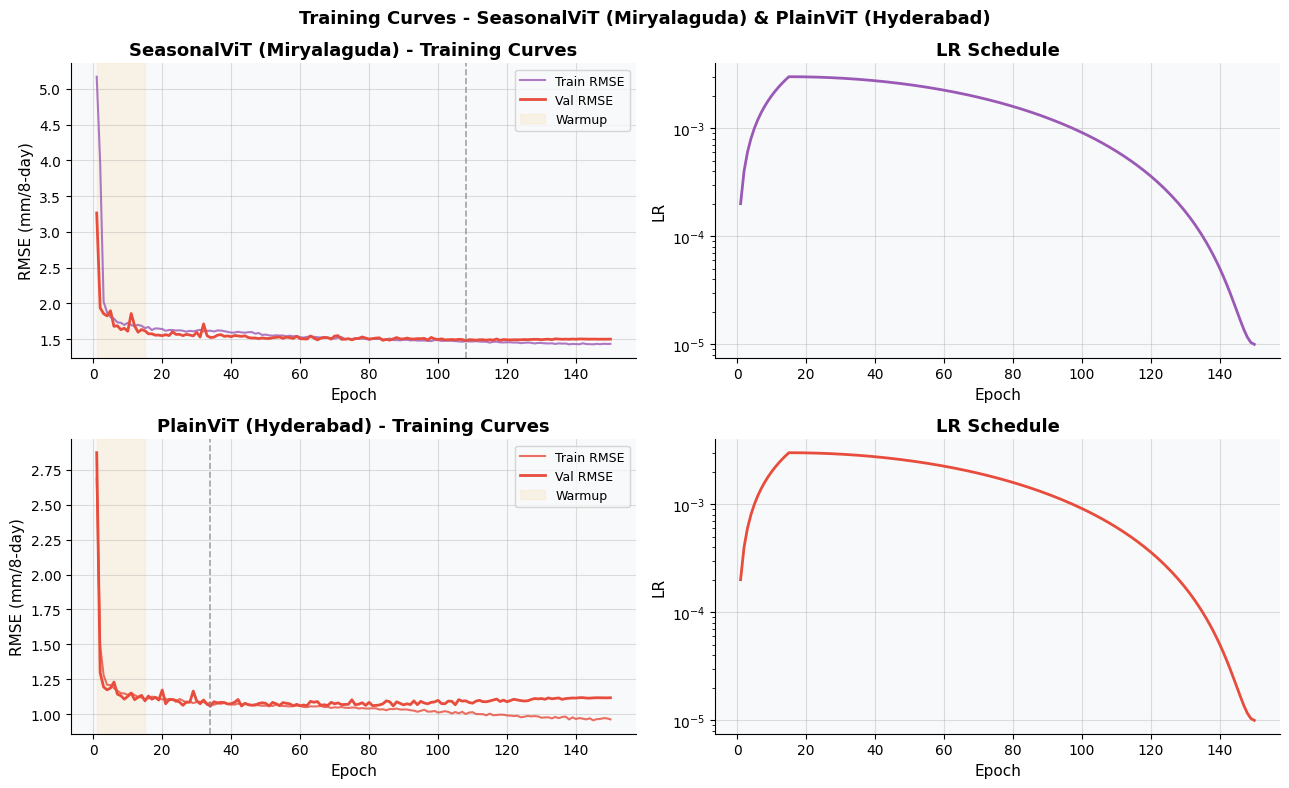

In [10]:
# Training curves - both models
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ep = np.arange(1, EPOCHS + 1)

for row, (hist, best_ep, best_rmse, label, color) in enumerate([
    (mir_history, mir_best_ep, mir_best_rmse, 'SeasonalViT (Miryalaguda)', VIT_COLOR),
    (hyd_history, hyd_best_ep, hyd_best_rmse, 'PlainViT (Hyderabad)',      HYD_COLOR),
]):
    ax = axes[row][0]
    ax.plot(ep, hist['train_rmse'], color=color, lw=1.5, alpha=0.8, label='Train RMSE')
    ax.plot(ep, hist['val_rmse'],   color='#e74c3c', lw=2.0, label='Val RMSE')
    ax.axvline(best_ep, color='gray', lw=1.2, ls='--', alpha=0.7)
    ax.axvspan(1, WARMUP_EP, alpha=0.08, color='orange', label=f'Warmup')
    ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (mm/8-day)')
    ax.set_title(f'{label} - Training Curves', fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[row][1]
    ax.plot(ep, hist['lr'], color=color, lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.set_title('LR Schedule', fontweight='bold')
    ax.set_yscale('log')

plt.suptitle('Training Curves - SeasonalViT (Miryalaguda) & PlainViT (Hyderabad)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Evaluation


In [11]:
def evaluate_model(model, dataloader, scaler_y, device, split_name=''):
    model.eval()
    all_preds, all_targets, all_sids = [], [], []
    with torch.no_grad():
        for X_b, sid_b, y_b in dataloader:
            X_b, sid_b = X_b.to(device), sid_b.to(device)
            pred = model(X_b[:, :len(FEATURES)], sid_b)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_b.numpy())
            all_sids.append(sid_b.cpu().numpy())
    preds   = scaler_y.inverse_transform(np.vstack(all_preds))
    targets = scaler_y.inverse_transform(np.vstack(all_targets))
    sids    = np.concatenate(all_sids)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae  = mean_absolute_error(targets, preds)
    r2   = r2_score(targets, preds)
    bias = np.mean(preds - targets)
    print(f'{split_name:18s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  Bias={bias:+.4f}')
    return preds.flatten(), targets.flatten(), sids, {'rmse':rmse,'mae':mae,'r2':r2,'bias':bias}

print('=== SeasonalViT - Miryalaguda ===')
mir_vp, mir_vt, mir_vsids, mir_val_m  = evaluate_model(mir_model, mir_val_dl,  scaler_mir_y, DEVICE, 'Validation')
mir_tp, mir_tt, mir_tsids, mir_test_m = evaluate_model(mir_model, mir_test_dl, scaler_mir_y, DEVICE, 'Test')

print()
print('=== PlainViT - Hyderabad ===')
hyd_vp, hyd_vt, hyd_vsids, hyd_val_m  = evaluate_model(hyd_model, hyd_val_dl,  scaler_hyd_y, DEVICE, 'Validation')
hyd_tp, hyd_tt, hyd_tsids, hyd_test_m = evaluate_model(hyd_model, hyd_test_dl, scaler_hyd_y, DEVICE, 'Test')


=== SeasonalViT - Miryalaguda ===
Validation          RMSE=1.4771  MAE=1.0916  R²=0.8982  Bias=+0.0778
Test                RMSE=1.4833  MAE=1.1038  R²=0.8981  Bias=+0.0839

=== PlainViT - Hyderabad ===
Validation          RMSE=1.0579  MAE=0.7665  R²=0.3582  Bias=-0.0223
Test                RMSE=1.0393  MAE=0.7598  R²=0.3306  Bias=-0.0256


In [12]:
# Per-season metrics - Miryalaguda test
print('=== Per-Season Test Metrics - SeasonalViT (Miryalaguda) ===')
for sid, name in [(1,'Kharif'),(0,'Rabi')]:
    mask = mir_tsids == sid
    if mask.sum() == 0: continue
    print(f'  {name:8s}: R²={r2_score(mir_tt[mask],mir_tp[mask]):.4f}  '
          f'RMSE={np.sqrt(mean_squared_error(mir_tt[mask],mir_tp[mask])):.4f}  '
          f'MAE={mean_absolute_error(mir_tt[mask],mir_tp[mask]):.4f}')


=== Per-Season Test Metrics - SeasonalViT (Miryalaguda) ===
  Kharif  : R²=0.2471  RMSE=1.2913  MAE=0.9814
  Rabi    : R²=0.4793  RMSE=1.6531  MAE=1.2262


## 7. Results Visualization


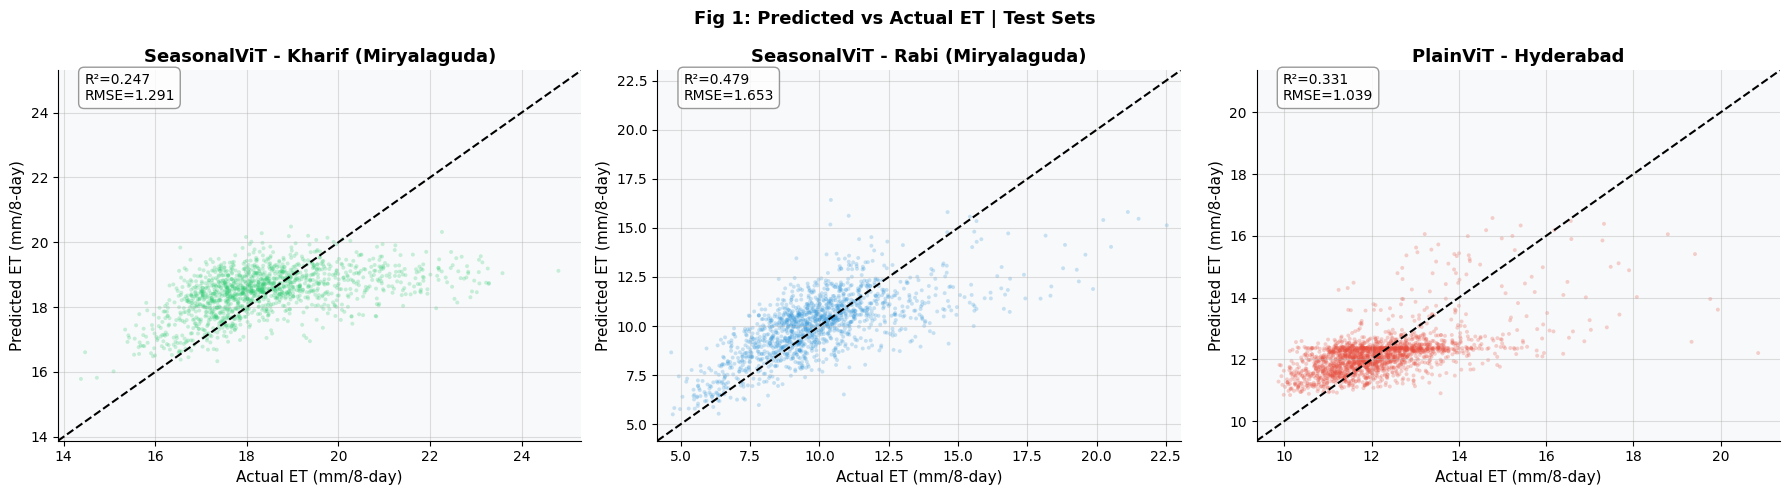

In [13]:
# Fig 1: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (mir_tp, mir_tt, mir_tsids, 1, 'SeasonalViT - Kharif (Miryalaguda)', KHARIF_COLOR),
    (mir_tp, mir_tt, mir_tsids, 0, 'SeasonalViT - Rabi (Miryalaguda)',   RABI_COLOR),
    (hyd_tp, hyd_tt, None,      None, 'PlainViT - Hyderabad',            HYD_COLOR),
]

for ax, (preds, targets, sids, sid_filter, title, color) in zip(axes, panels):
    if sid_filter is not None:
        mask = sids == sid_filter
        p_s, t_s = preds[mask], targets[mask]
    else:
        p_s, t_s = preds, targets

    ax.scatter(t_s, p_s, c=color, alpha=0.25, s=8, edgecolors='none')
    lo = min(t_s.min(), p_s.min()) - 0.5
    hi = max(t_s.max(), p_s.max()) + 0.5
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5)
    r2_s   = r2_score(t_s, p_s)
    rmse_s = np.sqrt(mean_squared_error(t_s, p_s))
    ax.text(0.05, 0.92, f'R²={r2_s:.3f}\nRMSE={rmse_s:.3f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.8))
    ax.set_xlabel('Actual ET (mm/8-day)'); ax.set_ylabel('Predicted ET (mm/8-day)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)

plt.suptitle('Fig 1: Predicted vs Actual ET | Test Sets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


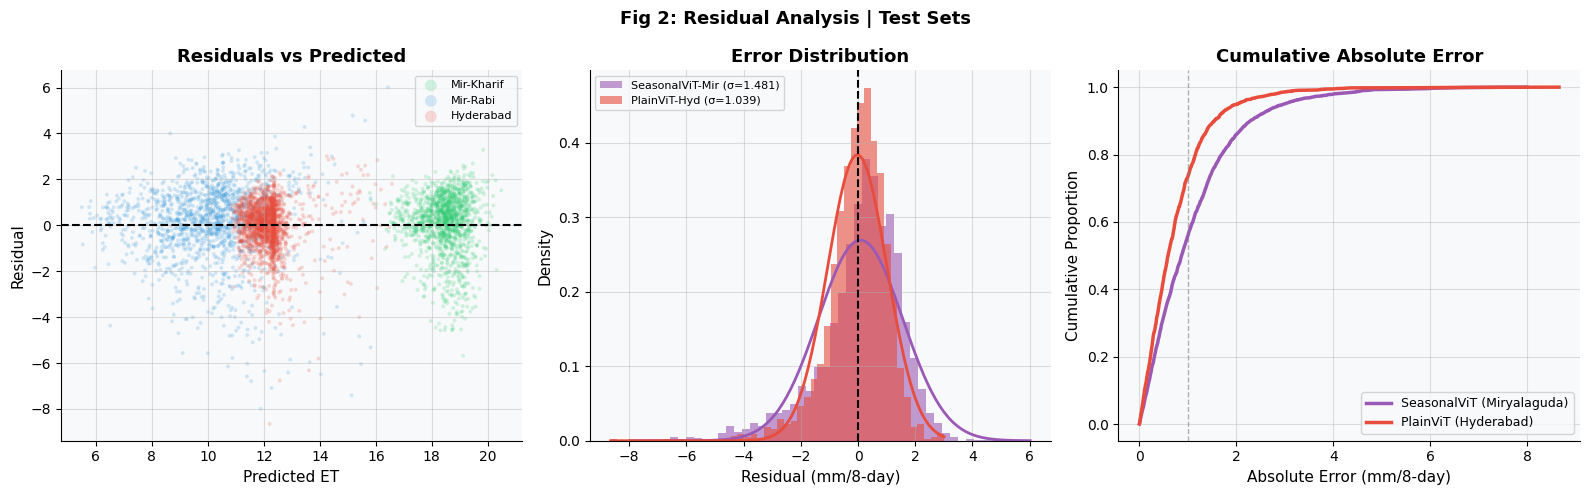

In [14]:
#  Fig 2: Residual analysis
res_mir = mir_tp - mir_tt
res_hyd = hyd_tp - hyd_tt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs predicted - Miryalaguda coloured by season
ax = axes[0]
for sid, sname, color in [(1,'Kharif',KHARIF_COLOR),(0,'Rabi',RABI_COLOR)]:
    mask = mir_tsids == sid
    ax.scatter(mir_tp[mask], res_mir[mask], c=color, alpha=0.2, s=8,
               label=f'Mir-{sname}', edgecolors='none')
ax.scatter(hyd_tp, res_hyd, c=HYD_COLOR, alpha=0.2, s=8,
           label='Hyderabad', edgecolors='none')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Predicted ET'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted', fontweight='bold')
ax.legend(markerscale=3, fontsize=8)

# Error distribution
ax = axes[1]
for res, color, label in [
    (res_mir, VIT_COLOR, f'SeasonalViT-Mir (σ={res_mir.std():.3f})'),
    (res_hyd, HYD_COLOR, f'PlainViT-Hyd (σ={res_hyd.std():.3f})'),
]:
    ax.hist(res, bins=50, color=color, alpha=0.6, density=True,
            edgecolor='none', label=label)
    mu, sig = norm.fit(res)
    xr = np.linspace(res.min(), res.max(), 200)
    ax.plot(xr, norm.pdf(xr, mu, sig), color=color, lw=2)
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Residual (mm/8-day)'); ax.set_ylabel('Density')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)

# Cumulative absolute error
ax = axes[2]
for res, color, label in [
    (res_mir, VIT_COLOR, 'SeasonalViT (Miryalaguda)'),
    (res_hyd, HYD_COLOR, 'PlainViT (Hyderabad)'),
]:
    se = np.sort(np.abs(res))
    ax.plot(se, np.arange(1,len(se)+1)/len(se), color=color, lw=2.5, label=label)
ax.axvline(1.0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel('Absolute Error (mm/8-day)'); ax.set_ylabel('Cumulative Proportion')
ax.set_title('Cumulative Absolute Error', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Fig 2: Residual Analysis | Test Sets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


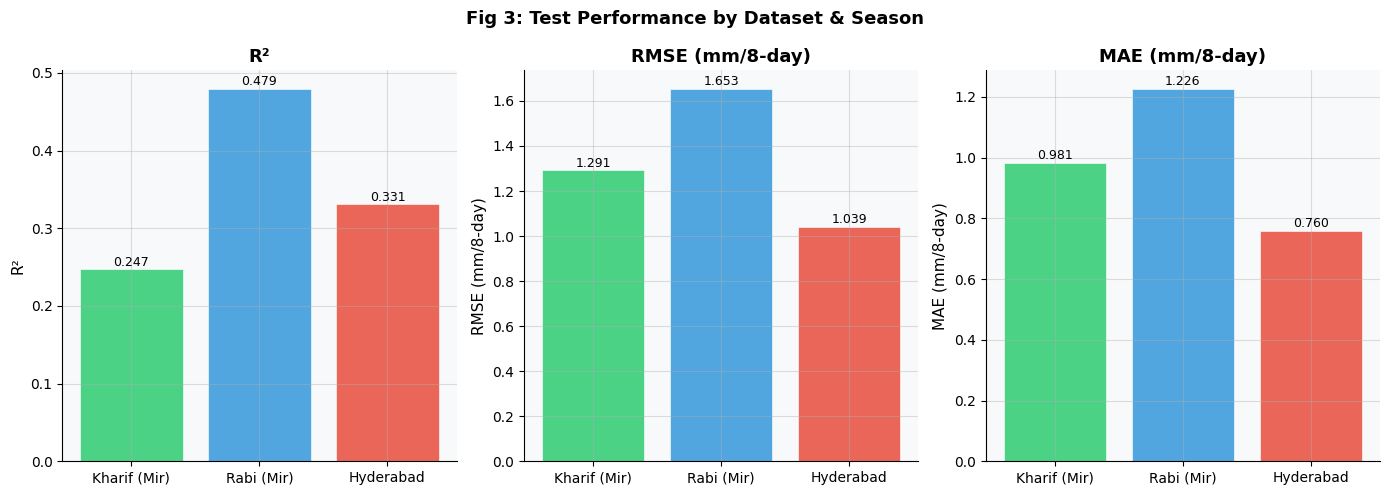

In [15]:
# Fig 3: Performance bar chart
rows = []
for sid, sname in [(1,'Kharif (Mir)'),(0,'Rabi (Mir)')]:
    mask = mir_tsids == sid
    if mask.sum() == 0: continue
    rows.append({'Dataset': sname,
                 'R2'  : r2_score(mir_tt[mask], mir_tp[mask]),
                 'RMSE': np.sqrt(mean_squared_error(mir_tt[mask], mir_tp[mask])),
                 'MAE' : mean_absolute_error(mir_tt[mask], mir_tp[mask])})
rows.append({'Dataset': 'Hyderabad',
             'R2'  : hyd_test_m['r2'],
             'RMSE': hyd_test_m['rmse'],
             'MAE' : hyd_test_m['mae']})

mdf = pd.DataFrame(rows)
colors = [KHARIF_COLOR, RABI_COLOR, HYD_COLOR]
x = np.arange(len(mdf))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, ylabel in zip(axes, ['R2','RMSE','MAE'], ['R²','RMSE (mm/8-day)','MAE (mm/8-day)']):
    bars = ax.bar(x, mdf[metric], color=colors[:len(mdf)], alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, mdf[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003*abs(v),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(mdf['Dataset'], fontsize=10)
    ax.set_ylabel(ylabel); ax.set_title(ylabel, fontweight='bold')

plt.suptitle('Fig 3: Test Performance by Dataset & Season', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Self-Attention Interpretability

Attention maps are extracted per dataset. For Miryalaguda the seasonal embedding conditions the attention; for Hyderabad it reflects pure spectral-terrain interactions.


In [16]:
def compute_avg_attention(model, X, season_ids, device, n_samples=300):
    idx = np.random.choice(len(X), min(n_samples, len(X)), replace=False)
    X_s  = X[idx].to(device)
    sid_s = season_ids[idx].to(device)
    attn_all = model.get_attention_weights(X_s[:, :len(FEATURES)], sid_s)
    return torch.stack(attn_all).mean(0).mean(0).numpy()

torch.manual_seed(SEED)
X_mir_te_t = torch.tensor(X_mir_te, dtype=torch.float32)
X_hyd_te_t = torch.tensor(X_hyd_te, dtype=torch.float32)

attn_maps = {}
for sid, sname in [(1,'Kharif (Miryalaguda)'),(0,'Rabi (Miryalaguda)')]:
    mask = mir_tsids == sid
    if mask.sum() > 0:
        attn_maps[sname] = compute_avg_attention(
            mir_model, X_mir_te_t[mask], sid_mir_te[mask], DEVICE)

attn_maps['Hyderabad'] = compute_avg_attention(
    hyd_model, X_hyd_te_t, dummy_sid_hte, DEVICE)

for k, v in attn_maps.items():
    print(f'Attention shape ({k}):', v.shape)


Attention shape (Kharif (Miryalaguda)): (9, 9)
Attention shape (Rabi (Miryalaguda)): (9, 9)
Attention shape (Hyderabad): (9, 9)


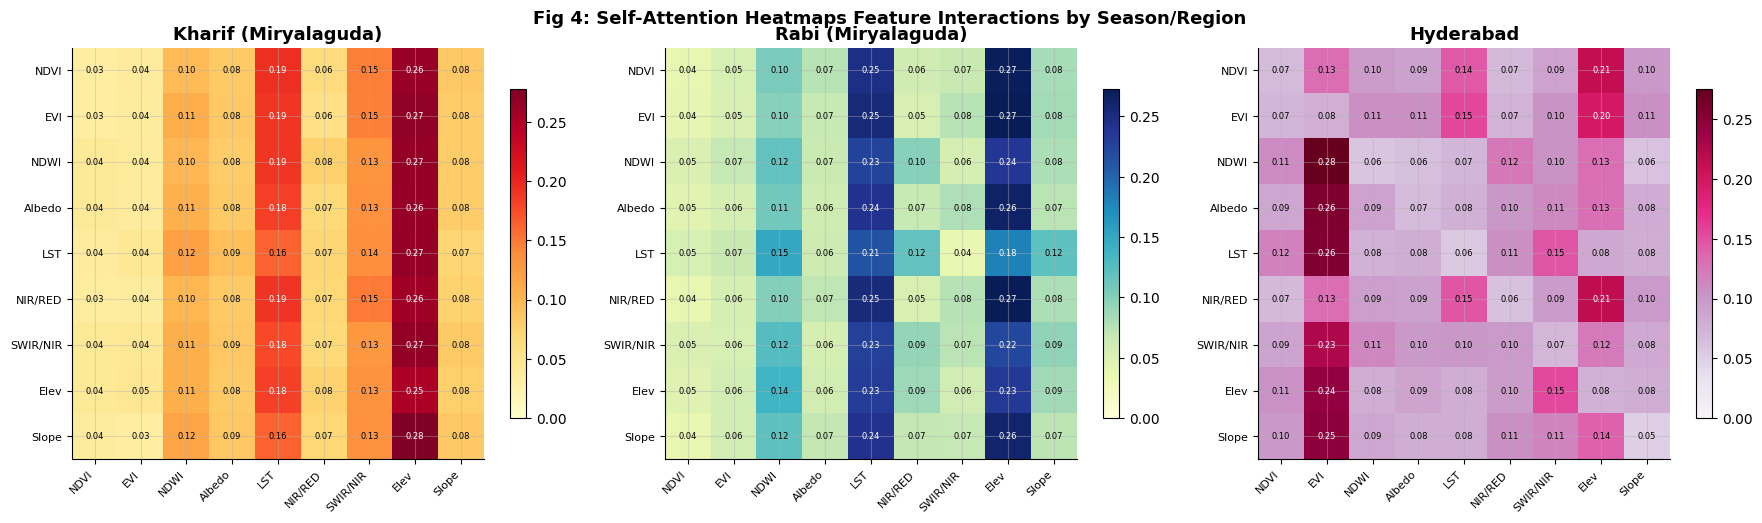

In [17]:
feat_labels = ['NDVI','EVI','NDWI','Albedo','LST','NIR/RED','SWIR/NIR','Elev','Slope']
cmaps_map = {'Kharif (Miryalaguda)':'YlOrRd', 'Rabi (Miryalaguda)':'YlGnBu', 'Hyderabad':'PuRd'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (sname, attn) in zip(axes, attn_maps.items()):
    im = ax.imshow(attn, cmap=cmaps_map[sname], vmin=0)
    ax.set_xticks(range(9)); ax.set_xticklabels(feat_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(9)); ax.set_yticklabels(feat_labels, fontsize=8)
    for i in range(9):
        for j in range(9):
            ax.text(j, i, f'{attn[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if attn[i,j]>attn.max()*0.6 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(sname, fontweight='bold')

plt.suptitle('Fig 4: Self-Attention Heatmaps Feature Interactions by Season/Region',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Spatial ET Maps - Predicted vs Actual

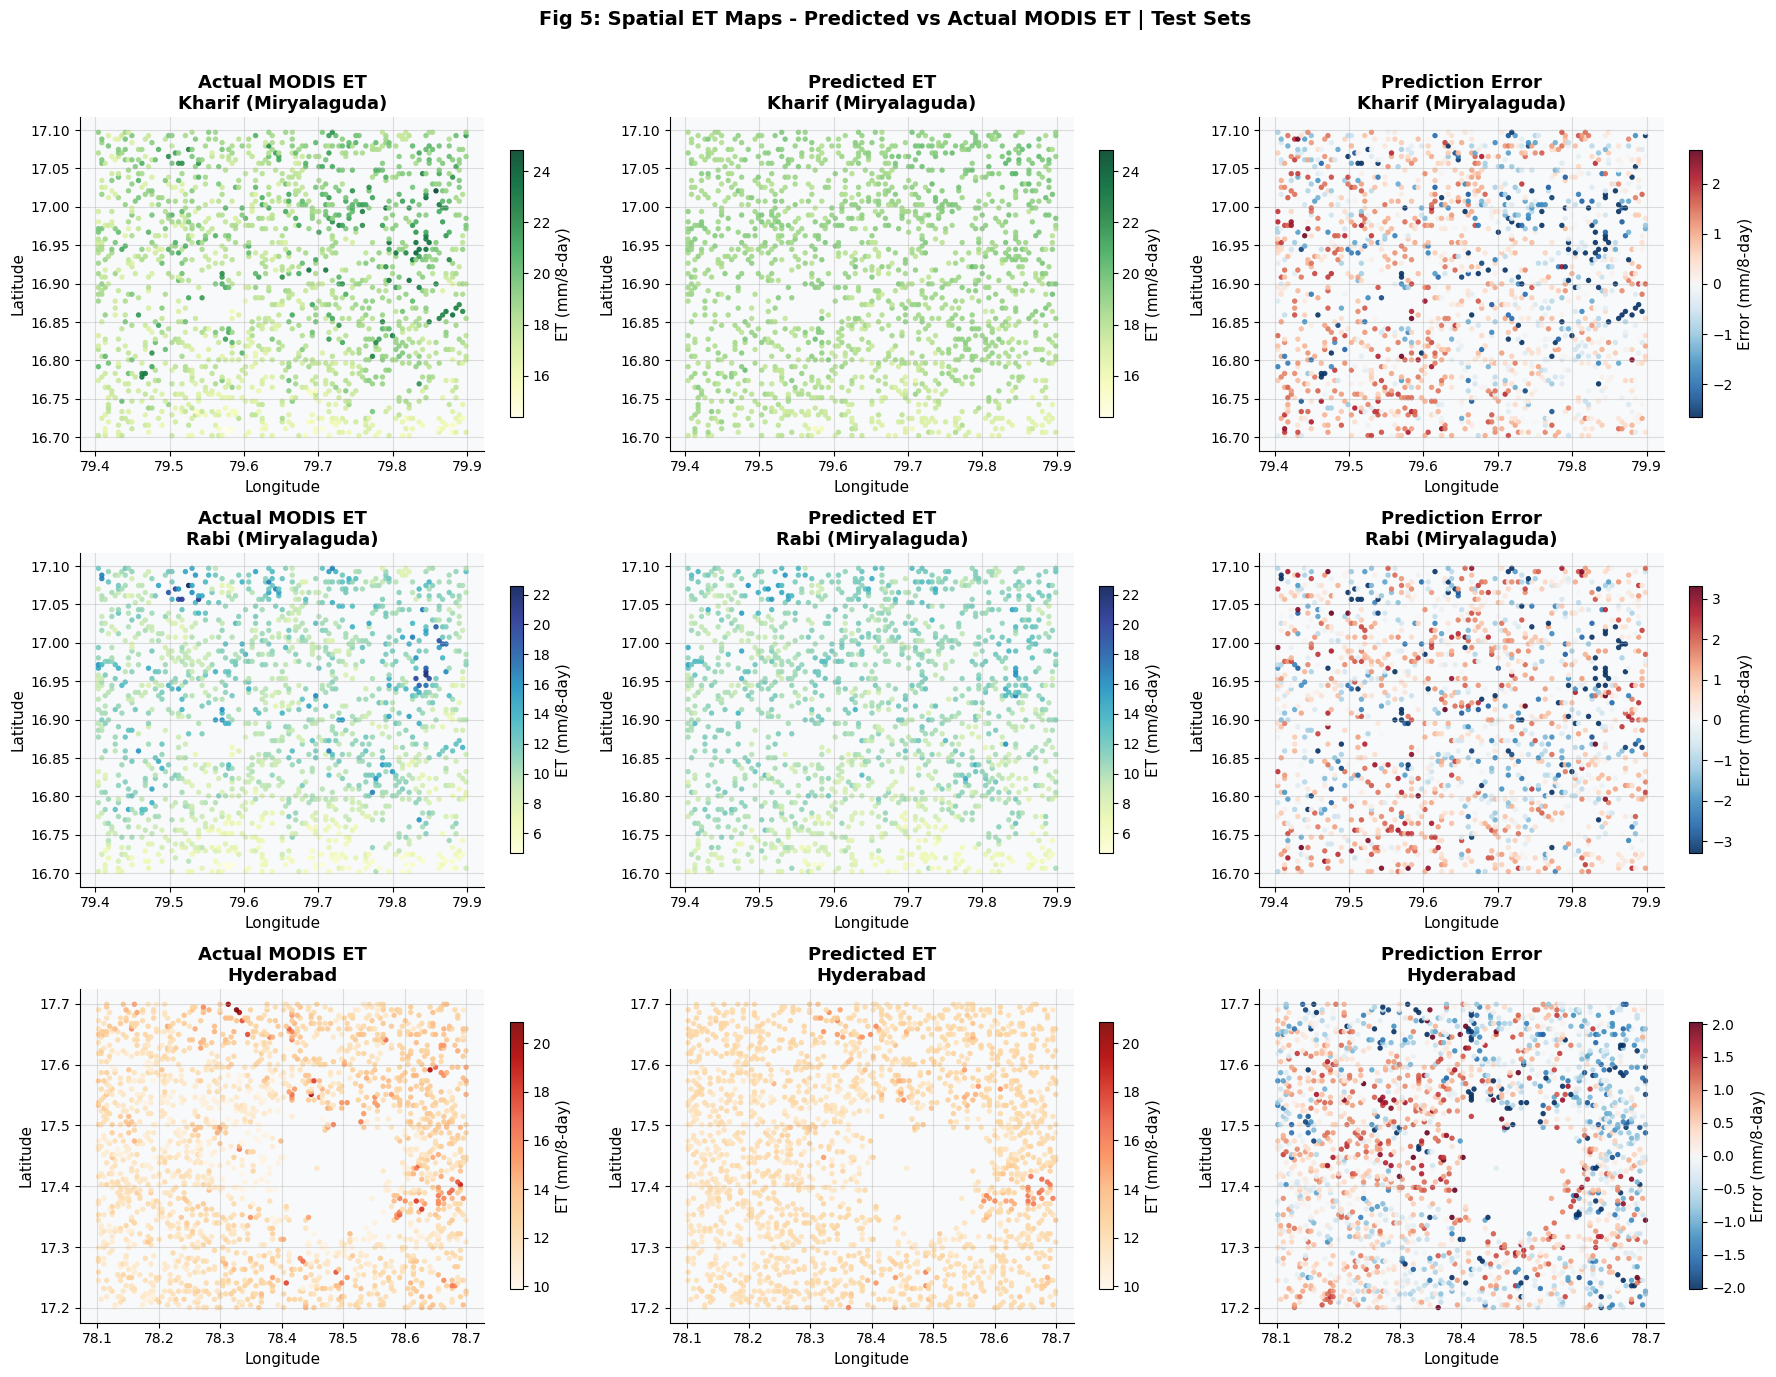

In [18]:
# Fig 5: Spatial ET maps
panels = [
    (mir_tp, mir_tt, mir_tsids, 1, mir_test, 'Kharif (Miryalaguda)', 'YlGn'),
    (mir_tp, mir_tt, mir_tsids, 0, mir_test, 'Rabi (Miryalaguda)',   'YlGnBu'),
    (hyd_tp, hyd_tt, None,     None, hyd_test, 'Hyderabad',           'OrRd'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, (preds, targets, sids, sid_f, df_src, sname, cmap) in enumerate(panels):
    if sid_f is not None:
        mask_s = sids == sid_f
        lats_s = df_src['lat'].values[mask_s]
        lons_s = df_src['lon'].values[mask_s]
        et_act = targets[mask_s]
        et_vit = preds[mask_s]
    else:
        lats_s = df_src['lat'].values
        lons_s = df_src['lon'].values
        et_act = targets
        et_vit = preds

    et_err = et_vit - et_act
    et_min = min(et_act.min(), et_vit.min())
    et_max = max(et_act.max(), et_vit.max())

    sc1 = axes[row][0].scatter(lons_s, lats_s, c=et_act, cmap=cmap, s=15,
                                vmin=et_min, vmax=et_max, edgecolors='none', alpha=0.9)
    plt.colorbar(sc1, ax=axes[row][0], label='ET (mm/8-day)', shrink=0.8)
    axes[row][0].set_title(f'Actual MODIS ET\n{sname}', fontweight='bold')

    sc2 = axes[row][1].scatter(lons_s, lats_s, c=et_vit, cmap=cmap, s=15,
                                vmin=et_min, vmax=et_max, edgecolors='none', alpha=0.9)
    plt.colorbar(sc2, ax=axes[row][1], label='ET (mm/8-day)', shrink=0.8)
    axes[row][1].set_title(f'Predicted ET\n{sname}', fontweight='bold')

    err_lim = np.percentile(np.abs(et_err), 95)
    sc3 = axes[row][2].scatter(lons_s, lats_s, c=et_err, cmap='RdBu_r', s=15,
                                vmin=-err_lim, vmax=err_lim, edgecolors='none', alpha=0.9)
    plt.colorbar(sc3, ax=axes[row][2], label='Error (mm/8-day)', shrink=0.8)
    axes[row][2].set_title(f'Prediction Error\n{sname}', fontweight='bold')

    for ax in axes[row]:
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle('Fig 5: Spatial ET Maps - Predicted vs Actual MODIS ET | Test Sets',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('fig5_spatial_et_maps.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Summary Table & Final Results


In [1]:
print('  SEASONAL VIT ET DOWNSCALING - MIRYALAGUDA + HYDERABAD, TELANGANA')
print()
print('Datasets')
print(f'  Miryalaguda Kharif : {len(df_kharif):,} rows')
print(f'  Miryalaguda Rabi   : {len(df_rabi):,} rows')
print(f'  Hyderabad          : {len(df_hyd):,} rows')
print()
print('── Models ──')
print(f'  SeasonalViT (Miryalaguda): {sum(p.numel() for p in mir_model.parameters() if p.requires_grad):,} params | 2 season tokens (Kharif/Rabi)')
print(f'  PlainViT    (Hyderabad)  : {sum(p.numel() for p in hyd_model.parameters() if p.requires_grad):,} params | no seasonal embedding')
print()
print('── Miryalaguda - SeasonalViT ──')
print(f'  Val  : R²={mir_val_m["r2"]:.4f}  RMSE={mir_val_m["rmse"]:.4f}  MAE={mir_val_m["mae"]:.4f}')
print(f'  Test : R²={mir_test_m["r2"]:.4f}  RMSE={mir_test_m["rmse"]:.4f}  MAE={mir_test_m["mae"]:.4f}')
for sid, sname in [(1,'Kharif'),(0,'Rabi')]:
    mask = mir_tsids == sid
    if mask.sum()>0:
        print(f'  Test {sname}: R²={r2_score(mir_tt[mask],mir_tp[mask]):.4f}  '
              f'RMSE={np.sqrt(mean_squared_error(mir_tt[mask],mir_tp[mask])):.4f}')
print()
print('── Hyderabad - PlainViT ──')
print(f'  Val  : R²={hyd_val_m["r2"]:.4f}  RMSE={hyd_val_m["rmse"]:.4f}  MAE={hyd_val_m["mae"]:.4f}')
print(f'  Test : R²={hyd_test_m["r2"]:.4f}  RMSE={hyd_test_m["rmse"]:.4f}  MAE={hyd_test_m["mae"]:.4f}')

  SEASONAL VIT ET DOWNSCALING - MIRYALAGUDA + HYDERABAD, TELANGANA

Datasets
  Miryalaguda Kharif : 9,736 rows
  Miryalaguda Rabi   : 9,736 rows
  Hyderabad          : 12,789 rows

— Models —
  SeasonalViT (Miryalaguda): 136,833 params | 2 season tokens (Kharif/Rabi)
  PlainViT    (Hyderabad)  : 136,705 params | no seasonal embedding

— Miryalaguda - SeasonalViT —
  Val  : R²=0.8982  RMSE=1.4771  MAE=1.0916
  Test : R²=0.8981  RMSE=1.4833  MAE=1.1038
  Test Kharif: R²=0.2471  RMSE=1.2913
  Test Rabi: R²=0.4793  RMSE=1.6531

— Hyderabad - PlainViT —
  Val  : R²=0.3582  RMSE=1.0579  MAE=0.7665
  Test : R²=0.3306  RMSE=1.0393  MAE=0.7598



## Architecture Summary

### SeasonalViT Miryalaguda
```
9 features → Linear(1→64) tokens
           → Feature Pos Emb + Seasonal Emb (Kharif=1 / Rabi=0, broadcast)
           → 4× TransformerEncoderLayer (Pre-LN, 4 heads, FFN=128)
           → Global Avg Pool → Linear(64→32→1) → ET
```

### PlainViT Hyderabad
```
9 features → Linear(1→64) tokens
           → Feature Pos Emb only  (no seasonal embedding)
           → 4× TransformerEncoderLayer (same backbone)
           → Global Avg Pool → Linear(64→32→1) → ET
```